# Signal-to-noise tradeoff with high efficiency (larger FOV)

In [1]:
from matplotlib import pyplot as plt
import numpy as np
from scipy.special import jv, kv
from scipy.special import j1 # Bessel function of the first kind of order 1, for the diffraction pattern calculation
from scipy.optimize import root_scalar
from scipy.constants import c, epsilon_0, mu_0, pi
import scipy.integrate as integrate

In [2]:
from scipy.optimize import brentq
# The Brent's method is a root-finding algorithm that combines the bisection method, the secant method, and 
# inverse quadratic interpolation. 
# https://en.wikipedia.org/wiki/Brent%27s_method
# It is designed to find roots of a continuous function within a specified interval where the function changes
#  sign. The method is efficient and robust, making it suitable for finding roots of nonlinear equations.

In [3]:
# # Given the X and Y roots for the LP01 mode from previous calculations
# X_root = 1.5590595758091075
# Y_root = 1.3985078062014993

def function_LP01(X, V):
    ""
    # Calculate Y based on the relationship Y^2 = V^2 - X^2
    Y = np.sqrt(V**2 - X**2)
    # Calculate the left-hand side and right-hand side of the equation using the Bessel functions
    lhs = X * jv(1, X) / jv(0, X)
    rhs = Y * kv(1, Y) / kv(0, Y)
    return lhs - rhs

def find_root(V, X_min, X_max):
    # Define a lambda function that takes X as input and uses the previously defined function f with the 
    # fixed V value. This allows us to use this function for root finding.
    function_m1 = lambda X: function_LP01(X, V)

    X_scan = np.linspace(X_min, X_max, 5000)
    F_scan = function_m1(X_scan) # Evaluate the function at the scan points

    bracket = None

    # We take length of scan - 1 because we are checking pairs of points for sign changes, 
    # -1 means we won't go out of bounds when checking F_scan[i + 1]
    for i in range(len(X_scan) - 1): # Loop through the length-1 of X_scan to find a sign change
        if F_scan[i] * F_scan[i + 1] < 0: # Check for a sign change
            x1 = X_scan[i]
            x2 = X_scan[i + 1]
            f1 = F_scan[i]
            f2 = F_scan[i + 1]

            # Skip non-finite values
            if not np.isfinite(f1) or not np.isfinite(f2):
                continue

            # sign chage detected between x1 and x2, we can use this as a bracket for root finding
            if f1*f2 < 0:
                bracket = (x1, x2) # Store the bracket where the sign change occurs
                break # Exit the loop after finding the first sign change

    if bracket is None:
        raise ValueError(f"No valid bracket found for V = {V:.6f}")

    X_root = brentq(function_m1, bracket[0], bracket[1]) # Use the found bracket for root finding
    Y_root = np.sqrt(V**2 - X_root**2)
    return X_root, Y_root


In [4]:
def calculate_electric_field(rho, X_root, Y_root):
    """ 
    Define a function to calculate the electric field distribution across the fibre 
    cross-section based on the roots found from the Bessel function equations. This function 
    will compute the electric field in both the core and cladding regions, normalise it, and 
    return both the normalised electric field and its intensity profile. 

    X_root: The root of the equation for the core region, which determines the behaviour of the electric field within the core.
    Y_root: The root of the equation for the cladding region, which determines the behaviour of the electric field in the cladding.
    rho: The normalised radius array (r/a) across which we want to calculate the electric field distribution.

    """

    # Step 2 - Create an array of zeros with the same shape as rho to store the electric field values
    E = np.zeros_like(rho)

    # Step 3 - Set the condition as the boundary between core and cladding, this helps to create a piecewise function for the electric field distribution
    core = rho <= 1
    cladding = rho > 1

    # Step 4 - Compute the electric field in the core region (rho <= 1) using the ordinary Bessel function J0.
    # E[core] uses conditional (boolean) assignment directly: values are assigned only where the condition is satisfied, allowing us to implement the piecewise solution of the wave equation without using loops.
    # Physically, this corresponds to applying the core solution E(rho) = J0(X*rho) only inside the fibre core.

    E[core] = jv(0, X_root * rho[core]) # Setting A = 1, multiplied by te Bessel function of zeroth order and ratio rho inside the core

    # Step 5 - Set the matching factor at the boundary (rho=1) as J0(X) / K0(Y), this makes the cladding field connect smoothly
    match_factor = jv(0,X_root) / kv(0,Y_root) 

    # Step 6 - Compute the electric field in the cladding region (rho > 1) using the modified Bessel function K0, multiplied by the matching factor to ensure continuity at the boundary
    E[cladding] = match_factor * kv(0, Y_root * rho[cladding])

    # Step 7 - Normalise the electric field distribution so that the maximum value is 1, this allows us to compare the relative field strength across the fibre cross-section
    E_norm = E / np.max(abs(E)) 

    # Step 8 - We also compute the intensity profile of the electric field, such that I represents the intensity profile and E represents the field amplitude. 
    I = np.abs(E_norm)**2

    return E_norm, I # note they are in normalised units

In [5]:
def coude_diffraction_limited_E_field(r, lam0, F, alpha, E_S):

    """
    Function for calculating the E-field at diffraction limited E_field, specifically for
    the Coude focus (or a focus that has a long focal length resulting in high magnification)

    r: radial coordinate in the image plane (in meters)
    lam0: wavelength of the incoming beam in vacuum (in meters)
    F: focal ratio (f/#) of the telescope, defined as the focal length divided by the diameter of the primary mirror
    alpha: ratio of the central obstruction diameter to the primary mirror diameter, which affects the diffraction pattern and thus the E-field distribution at the focus
    E_S: amplitude of the incoming E-field, which can be set to 1 for normalisation purposes
    """

    s = np.pi * r / (lam0 * F) # Normalised radial coordinate for the diffraction pattern

    # Use safe division so the s=0 limit is finite (2*J1(x)/x -> 1 as x->0)
    airy_term = np.divide(2 * j1(s), s, out=np.ones_like(s), where=s != 0)
    obstruction_term = np.divide(2 * j1(alpha * s), alpha * s, out=np.ones_like(s), where=(alpha * s) != 0)

    # The electric field of image found from the diffraction pattern of the telescope aperture, modified by the 
    # central obstruction, multiplied by the fibre mode field distribution to get the resulting image field 
    # distribution at the fibre input. Note: zero division at centre is artificially set to 1 
    E_image = E_S * (airy_term - alpha**2 * obstruction_term)

    # Intensity of the incoming beam forming an image at the fibre input 
    I_image = np.abs(E_image)**2

    return E_image, I_image

In [6]:
def demagnified_diffraction_limited_E_field(r, lam0, F, alpha, E_S, Magnification):
    """
    r: the radius array created, representing distance vector in the ribre radius
    
    lam0: wavelength of the light in air

    F: focal ratio F=f/D at the focus or after re-imager

    alpha: the ratio of central obstration to primary mirror diameter

    E_S: amplitude of the E-field of image normalised (assumed) to equal to 1 here

    Magnification: different to the magnification measurement between image at the telescope 
    and focus, the Magnification here refers to the required scale of "magnification" or inverted 
    demagnification required for the re-imaging optics

    """

    s_demag = np.pi * r / (lam0 * F * Magnification) # Normalised radial coordinate for the diffraction pattern after demagnification

    # Use safe division so the s=0 sample does not produce NaN
    airy_term_demag = np.divide(2 * j1(s_demag), s_demag, out=np.ones_like(s_demag), where=s_demag != 0)
    obstruction_term_demag = np.divide(2 * j1(alpha * s_demag), alpha * s_demag,
        out=np.ones_like(s_demag),
        where=(alpha * s_demag) != 0,
    )

    # The electric field of image found from the diffraction pattern of the telescope aperture, modified by the 
    # central obstruction, multiplied by the fibre mode field distribution to get the resulting image field distribution at the fibre input.
    E_image_demag = E_S * (airy_term_demag - alpha**2 * obstruction_term_demag)

    # Intensity of the incoming beam forming an image at the fibre input 
    I_image_demag = np.abs(E_image_demag)**2

    return E_image_demag, I_image_demag

In [7]:
# The entire radial range
def coupling_efficiency_1d(E_image_demag, E_smf, r):
    """
    Input: 
    E_image_demag: electric field of demagnified image
    E_smf: electric field of single mode fibre

    Output: 
    numerator = |∫ E_image_demag * conj(E_smf) * 2πr dr|^2
    denominator = ∫ |E_smf|^2 * 2πr dr * ∫ |E_image_demag|^2 * 2πr dr
    efficiency eta: we integrate from infinitely large radius to the centre (but here 
    instead of infinity we use the finite range of r that we have where largest r must be larger
    than cladding radius to capture the Evanescent field distribution)
    
    """
    numerator = np.abs(np.trapezoid(E_image_demag * np.conjugate(E_smf) * 2*np.pi*r, x=r))**2
    denominator = np.trapezoid(np.abs(E_smf)**2 * 2*np.pi*r, x=r) * np.trapezoid(np.abs(E_image_demag)**2 * 2*np.pi*r, x=r)
    # Calculate efficiency:
    eta = numerator / denominator

    return eta, numerator, denominator

In [8]:
# wavelength of beam in vacuum
lam0 = 1.5e-6 
# fibre core radius
a = 5e-6 
# numerical aperture of fibre
NA = 0.1 

# Calculate the normalised frequency (V-number) of the fibre
V = 2 * pi * (a / lam0) * NA
print(f"V-number of the fibre: {V:.2f}")

V-number of the fibre: 2.09


In [9]:
# Approximate number of modes that the fibre can support using the V-number
M = V**2 / 4
print(f"Approximate number of modes that the fibre can support: {M:.2f}")

Approximate number of modes that the fibre can support: 1.10


In [10]:
X_min = 0 + 1e-8  # slightly above 0 to avoid singularity at Y=V
X_max = V - 1e-8  # slightly less than V to avoid singularity at Y=0

X_root, Y_root = find_root(V, X_min, X_max)

print("X root =", X_root)
print("Y root =", Y_root)

# Calculate the electric field distribution for the fundamental mode (LP01) in a step-index fibre
# Step 1- Create the radius array for plotting the electric field distribution
rho = np.linspace(0, 100, 5000) # From 0 to 100 times the core radius
print(f"Radius array (rho) created with {len(rho)} points.")

X root = 1.5590595758091206
Y root = 1.3985078062014846
Radius array (rho) created with 5000 points.


In [11]:
# Calculate electric field and intensity profiles using the function 
E_smf, I_smf = calculate_electric_field(rho, X_root, Y_root)
print(E_smf.shape, I_smf.shape)

(5000,) (5000,)


In [12]:
# Define a radial grid
r = rho * a # keep in metres

# Let's assume the focal ratio f/# is 49.9, where the focal length is 399m and D=8.0m (effectively)
F = 49.9

print(f"Radius range (r) in microns: {r[0] * 1e6:.2f} µm to {r[-1] * 1e6:.2f} µm")
print(f"Focal ratio (f/#) ~ {F:.4f}")


Radius range (r) in microns: 0.00 µm to 500.00 µm
Focal ratio (f/#) ~ 49.9000


Using information from ESO website: https://www.eso.org/sci/facilities/paranal/telescopes/ut/m1unit.html#:~:text=Mounting%20of%20the%20axial%20interfaces,down%20to%20sub%2Dmicron%20accuracy. 


In [13]:
# Define the diffraction limited E-field

# Not sure how big the obstruction is, assume it's 11.1 meters in diameter 
D_M1 = 8.0 # Diameter of the primary mirror in meters
D_obstruction = 1.0 # Diameter of the central obstruction in meters
alpha = D_obstruction / D_M1 # Ratio of the central obstruction to the primary mirror diameter

# Assume E_S = 1m exactly for the amplitude of the E-field
E_S = 1

In [14]:
# Define a radial grid
r = rho * a # keep in metres

# Let's assume the focal ratio f/# is 49.9, where the focal length is 399m and D=8.0m (effectively)
F = 49.9

print(f"Radius range (r) in microns: {r[0] * 1e6:.2f} µm to {r[-1] * 1e6:.2f} µm")
print(f"Focal ratio (f/#) ~ {F:.4f}")

Radius range (r) in microns: 0.00 µm to 500.00 µm
Focal ratio (f/#) ~ 49.9000


Using information from ESO website: https://www.eso.org/sci/facilities/paranal/telescopes/ut/m1unit.html#:~:text=Mounting%20of%20the%20axial%20interfaces,down%20to%20sub%2Dmicron%20accuracy. 


Since we assumed a numerical aperture of $\mathrm{NA} \approx 0.1$, which corresponds to a focal ratio of approximately $F \approx 5$ using the relation $\mathrm{NA} \approx 1/(2F)$.

At the VLT coudé focus, the beam has a much slower focal ratio of $F \approx 49.9$. To match the fibre acceptance, re-imaging optics are used to convert this beam to the desired injection focal ratio.

The required magnification (M = output size / input size) is therefore given by the ratio of the focal ratios,

$$
M = \frac{F_{\mathrm{inj}}}{F_{\mathrm{coud\acute{e}}}} = \frac{5}{49.9} \approx 0.10,
$$

corresponding to a demagnification of approximately 10×.

In [15]:
# Radius of airy disk at the first minimum after demagnification
r_airy = 1.22 * lam0 * F
print(f"Radius of airy disk at the first minimum: {r_airy} meters")

Magnification = 5 / 49.9
r_airy_demag = (1.22*lam0 * F) * Magnification

print(f"Radius of airy disk at the first minimum after demagnification: {r_airy_demag} meters")

Radius of airy disk at the first minimum: 9.131700000000001e-05 meters
Radius of airy disk at the first minimum after demagnification: 9.15e-06 meters


But in reality we use $\lambda F$ the diffracion scale as the size of the image, and we use this value when we are estimating the coupling and matching fibre size. 

In [16]:
r_image_demag = (lam0 * F) * Magnification

print(f"Radius of airy disk at the first minimum after demagnification: {r_image_demag} meters")

Radius of airy disk at the first minimum after demagnification: 7.5e-06 meters


In [17]:
E_image_demag, I_image_demag = demagnified_diffraction_limited_E_field(r, lam0, F, alpha, E_S, Magnification)
print(E_image_demag.shape, I_image_demag.shape)

(5000,) (5000,)


# Coupling efficiency as a functino of core radius

## Efficiency as a function of core radius for SMF

Since V $\leq$ 2.405 for a single mode fibre, the maximum core radius for a single mode fibre would be ~5.74 $\mu m$. 

In [18]:
V_max_single = 2.405 # The cutoff V-number for single-mode operation in a step-index fibre
a_max_single = V_max_single * lam0 / (2 * np.pi * NA)
print(f"Maximum core radius for single-mode operation: {a_max_single*1e6:.4f} microns")

Maximum core radius for single-mode operation: 5.7415 microns


In [19]:
def efficiency_vs_core_radius(core_radius_range, cladding_radius_max, lam0, NA, F, alpha, E_S, Magnification):
    
    efficiency_array = np.zeros_like(core_radius_range)
    for i, a in enumerate(core_radius_range):
        V = 2 * np.pi * (a / lam0) * NA # Calculate the V-number for the given radius
        X_min = 0 + 1e-8
        X_max = V - 1e-8
        # Find the X and Y roots for the given core radius a
        X_root, Y_root = find_root(V, X_min, X_max)
        # define a normalised radius r / a, with maximum at cladding size 125/2 micron
        fibre_rho = np.linspace(0, cladding_radius_max / a, 1000) 
        fibre_r = fibre_rho * a
        # Fibre field
        E_smf, I_smf = calculate_electric_field(fibre_rho, X_root, Y_root)
        # Image field
        E_image, I_image = demagnified_diffraction_limited_E_field(fibre_r, lam0, F, alpha, E_S, Magnification)

        # Calculate coupling efficiency
        eta, numerator, denominator = coupling_efficiency_1d(E_image, E_smf, r=fibre_r)
        # Store the efficiency in the array corresponding to the current core radius, using np.where 
        # to find the index where core_radius_range equals a
        efficiency_array[i] = eta

        if a==core_radius_range[0]: # plot first one for visualisation
            plt.figure(figsize=(8,4))
            plt.plot(fibre_r, E_smf, color='royalblue')
            plt.axvline(a, color='gray', linestyle='--') # Add a horizontal line at y=0 for reference
            plt.xlabel('radius (m)')
            plt.ylabel('Normalised E-field amplitude')
            plt.title(f'E-smf at a={a} m')
            plt.figure(figsize=(8,4))
            plt.plot(fibre_r, E_image, color='firebrick')
            plt.axvline(a, color='gray', linestyle='--') # Add a horizontal line at y=0 for reference
            plt.xlabel('radius (m)')
            plt.ylabel('Normalised E-field amplitude')
            plt.title(f'E-image at a={a} m')
    return efficiency_array

In [20]:
core_radius_range = np.linspace(5e-6, 5.7415e-6, 1483 + 1) # from 5 to 5.75 microns in meters
# efficiency_array = np.zeros_like(core_radius_range)

# The cladding radius should be set to 125/2 micron
cladding_radius_max = 125e-6 / 2

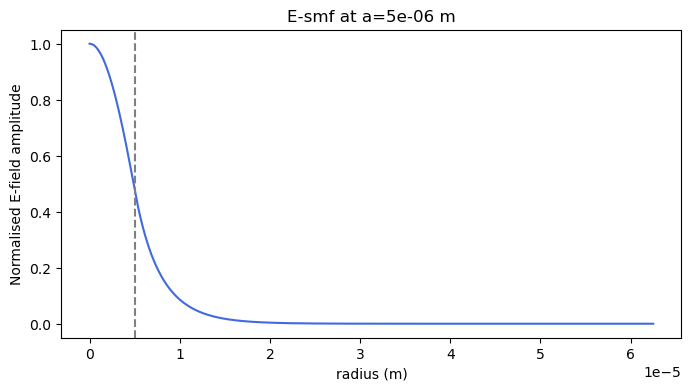

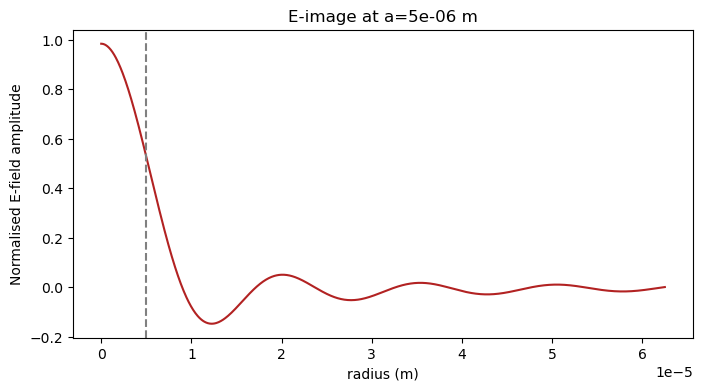

In [21]:
efficiency_array_signal = efficiency_vs_core_radius(core_radius_range, cladding_radius_max, lam0, NA, F, alpha, E_S, Magnification)

In [22]:
index = np.argmax(efficiency_array_signal)
print(f'The most optimal radius occurs at {core_radius_range[index]} with an efficiency of {efficiency_array_signal[index]}.' )

The most optimal radius occurs at 5.6605e-06 with an efficiency of 0.7399981624009804.


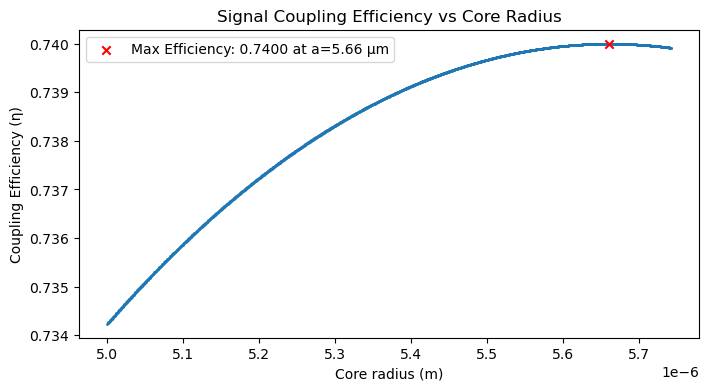

In [23]:
plt.figure(figsize=(8,4))
plt.scatter(core_radius_range, efficiency_array_signal, s=1, marker='o')
plt.scatter(core_radius_range[index], efficiency_array_signal[index], color='red', marker = 'x',
            label=f'Max Efficiency: {efficiency_array_signal[index]:.4f} at a={core_radius_range[index]*1e6:.2f} µm')
plt.xlabel('Core radius (m)')
plt.ylabel('Coupling Efficiency (η)')
plt.title('Signal Coupling Efficiency vs Core Radius')
plt.legend()

## Simulate a E-field for noise 

In [24]:
# The intensity and electric field would be nearly uniform for the background when 
# pointing to a patch of sky
E_uniform = np.ones_like(r) * 1.2
I_uniform = np.abs(E_uniform) **2

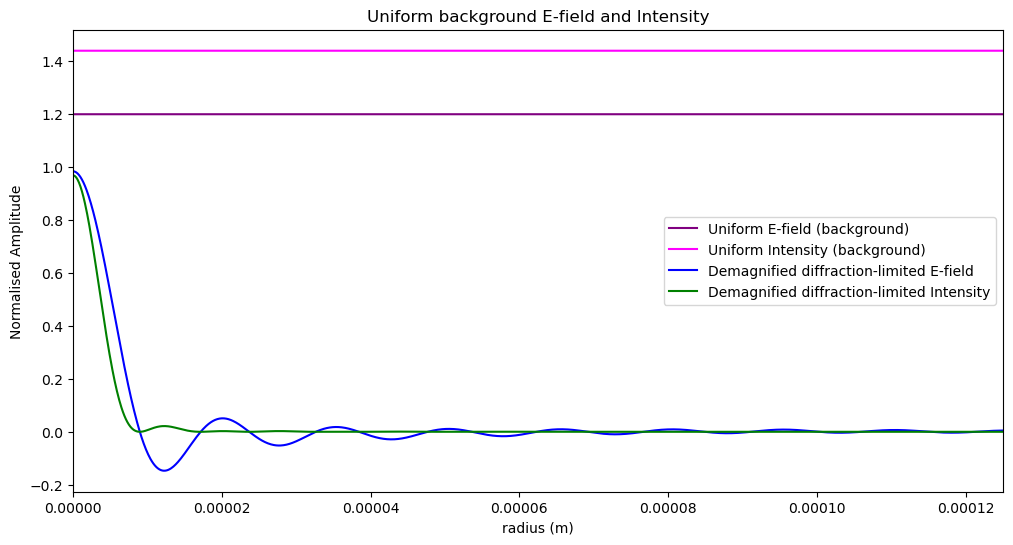

In [25]:
# Haha
plt.figure(figsize=(12,6))
plt.plot(r, E_uniform, label='Uniform E-field (background)', color='purple')
plt.plot(r, I_uniform, label='Uniform Intensity (background)', color='magenta')
plt.plot(r, E_image_demag, label='Demagnified diffraction-limited E-field', color='blue')
plt.plot(r, I_image_demag, label='Demagnified diffraction-limited Intensity', color='green')
plt.xlim(0,125e-6)
plt.xlabel("radius (m)")
plt.ylabel("Normalised Amplitude")
plt.title("Uniform background E-field and Intensity")
plt.legend()
plt.show()

In [26]:
def efficiency_vs_core_radius_noise_only(core_radius_range, cladding_radius_max, lam0, NA, F, 
                                         alpha, E_S, Magnification):
    efficiency_array_noise_only = np.zeros_like(core_radius_range)
    for a in core_radius_range: 
        V = 2 * np.pi * (a / lam0) * NA # Calculate the V-number for the given radius
        X_min = 0 + 1e-8
        X_max = V - 1e-8
        # Find the X and Y roots for the given core radius a
        X_root, Y_root = find_root(V, X_min, X_max)
        # define a normalised radius r / a, with maximum at cladding size 125/2 micron
        fibre_rho = np.linspace(0, cladding_radius_max / a, 1000) 
        fibre_r = fibre_rho * a
        # Fibre field
        E_smf, I_smf = calculate_electric_field(fibre_rho, X_root, Y_root)
        # Background field
        E_uniform = np.ones_like(fibre_r) * 1.2
        I_uniform = np.abs(E_uniform) **2

        # Calculate coupling efficiency
        eta, numerator, denominator = coupling_efficiency_1d(E_uniform, E_smf, r=fibre_r)
        # Store the efficiency in the array corresponding to the current core radius, using np.where 
        # to find the index where core_radius_range equals a
        efficiency_array_noise_only[np.where(core_radius_range == a)] = eta

        if a==core_radius_range[0]:
            plt.figure(figsize=(8,4))
            plt.plot(fibre_r, E_smf, color='royalblue')
            plt.axvline(a, color='gray', linestyle='--') # Add a horizontal line at y=0 for reference
            plt.xlabel('radius (m)')
            plt.ylabel('Normalised E-field amplitude')
            plt.title(f'E-smf at a={a} m')
            plt.figure(figsize=(8,4))
            plt.plot(fibre_r, E_uniform, color='firebrick')
            plt.axvline(a, color='gray', linestyle='--') # Add a horizontal line at y=0 for reference
            plt.xlabel('radius (m)')
            plt.ylabel('Normalised E-field amplitude')
            plt.title(f'E-image at a={a} m')
    return efficiency_array_noise_only

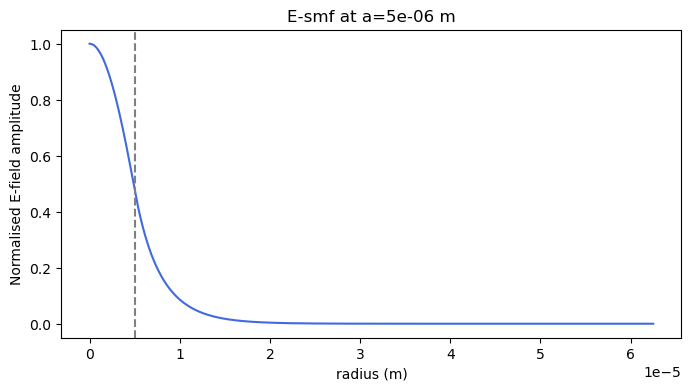

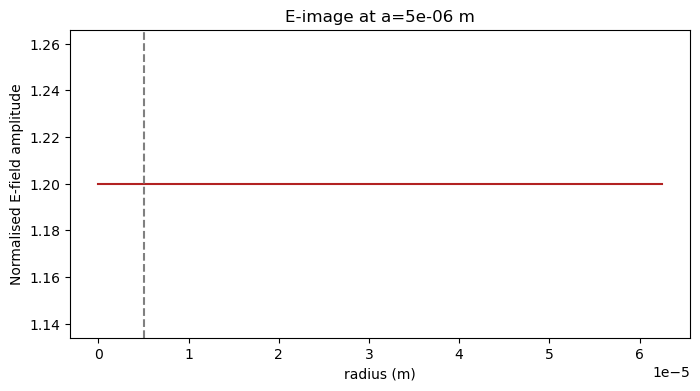

In [27]:
# efficiency_array_noise_only = np.zeros_like(core_radius_range)
efficiency_array_noise = efficiency_vs_core_radius_noise_only(core_radius_range, cladding_radius_max, lam0, NA, F, 
                                         alpha, E_S, Magnification)

/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_35652/3678072642.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


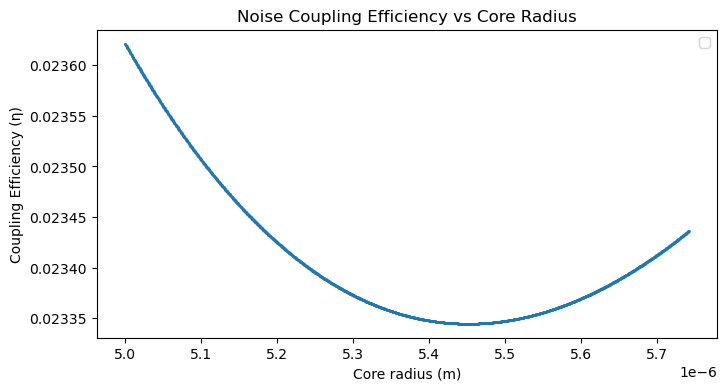

In [28]:
plt.figure(figsize=(8,4))
plt.scatter(core_radius_range, efficiency_array_noise, s=1, marker='o')
# plt.scatter(core_radius_range[index], efficiency_array[index], color='red', marker = 'x',
            # label=f'Max Efficiency: {efficiency_array[index]:.4f} at a={core_radius_range[index]*1e6:.2f} µm')
plt.xlabel('Core radius (m)')
plt.ylabel('Coupling Efficiency (η)')
plt.title('Noise Coupling Efficiency vs Core Radius')
plt.legend()

## Signal to Noise Ratio

- **Signal**: light from the source that is coupled into the fibre  
- **Background**: sky emission entering the fibre  
- **Noise**: assumed to be dominated by Poisson fluctuations of the **background ONLY **. 

### Signal (Point Source)

The signal is computed by integrating the image intensity over the fibre input plane / image (focal) plane by integrating the intensity over the fibre cross-section. 

For a circularly symmetric point spread function (PSF):

$$
S = 2\pi \int I_{\text{image}}(r)\, r\, dr
$$

where \(r\) is the physical radius at the fibre input (in meters). This gives the total power (or counts) entering the fibre from the source.

In practice, for a **single-mode fibre (SMF)**, the detected signal is determined by the **overlap between the image field and the fibre mode**. 

The coupled signal is then:

$
S_{\text{coupled}} \propto \eta
$

This formulation accounts for the fact that the fibre acts as a **mode filter**, not a simple geometric aperture. 

Note that the Signal of a point source is integrated over the image intensity, which gives S(r) in units of: 
$[\mathrm{counts} \; \mathrm{s}^{-1} \, \mathrm{m}^{-2}]$

### Background (Sky Noise)

The sky background is assumed to be spatially uniform, with **surface** brightness:

$$
I_{\text{flat}} \;\; [\mathrm{counts} \; \mathrm{s}^{-1} \, \mathrm{m}^{-2} \, \mathrm{arcsec}^{-2}]
$$

Since the background is uniform, the total background is simply:

$$
B = I_{\text{flat}} \times \Omega_{\text{aperture}}
$$

The fibre core radius $$a$$ is defined in physical units (m), so it must be converted to an angular field of view using the plate scale:

$$
\text{FOV} = 2a \times (\text{plate scale})
$$

The corresponding angular area is:

$$
\Omega_{\text{aperture}} = \pi \left(\frac{\text{FOV}}{2}\right)^2
$$

---

### Final Expression

$$
\boxed{
B = \pi \, I_{\text{flat}} \left(\frac{\text{FOV}}{2}\right)^2
}
$$

---

### Key Point

The signal is integrated over physical area, while the background is defined per angular area. Therefore, $$a^2$$ must be converted to $$\text{FOV}^2$$ to ensure consistent units.


In [29]:
I_flat = 1.2 **2 # flat intensity of the background noise across the fibre input plane, in normalised units
rad_to_arcsec = (180 / np.pi) * 3600 # conversion factor from radians to arcseconds

FOV_array = np.zeros_like(core_radius_range)
snr_array = np.zeros_like(core_radius_range)
signal_array = np.zeros_like(core_radius_range)
background_array = np.zeros_like(core_radius_range)

plate_scale_coude = rad_to_arcsec / (F * D_M1) # in arcseconds per meter at the focal plane
plate_scale_demag = plate_scale_coude / Magnification # in arcseconds per meter at the fibre input plane

for i, a in enumerate(core_radius_range): 

    V = 2 * np.pi * (a / lam0) * NA # Calculate the V-number for the given radius
    X_min = 0 + 1e-8
    X_max = V - 1e-8
    # Find the X and Y roots for the given core radius a
    X_root, Y_root = find_root(V, X_min, X_max)
    # define a normalised radius r / a, with maximum at cladding size 125/2 micron
    fibre_rho = np.linspace(0, cladding_radius_max / a, 10000) 
    fibre_r = fibre_rho * a

    # core_mask = fibre_r <= a # Create a mask for the core region where the fibre can couple light

    # Fibre field
    E_smf, I_smf = calculate_electric_field(fibre_rho, X_root, Y_root)
    # Image field
    E_image, I_image = demagnified_diffraction_limited_E_field(fibre_r, lam0, F, alpha, E_S, Magnification)

    # Calculate Field of View for the fibre
    FOV = plate_scale_demag * 2*a # in arcseconds 

    r_FOV = np.linspace(0, FOV, 10000) * plate_scale_demag # Convert FOV from arcseconds to meters at the fibre input plane for the core region
    
    Signal = 2*np.pi * integrate.simpson(I_image * fibre_r, x=fibre_r) # Total signal coupled into the fibre, integrating over the fibre cross-section
    Background = np.pi * I_flat * (FOV / 2) **2  # Total noise coupled into the fibre, integrating over the fibre cross-section

    snr = Signal / np.sqrt(Background) # Signal-to-noise ratio, assuming noise is dominated by the background and follows Poisson statistics

    FOV_array[i] = FOV
    snr_array[i] = snr
    signal_array[i] = Signal
    background_array[i] = Background


### Note: Why include the signal up to cladding
In optical waveguides, we distinguish stably propagating, lossless modes as guided modes and their unbounded, lossy counterparts as radiation modes. 
The guided modes are eigenmodes inside the core, and radiation modes correspond to the exponentially decaying component in the cladding. 

Even though the efficiency contribution via the overlap integral is small in the cladding, we cannot make a gross assuption that ignores the signal propagating as radiation loss in the cladding. Instead the 'relative' signal is the efficiency of the image electric cield multiplied by the field of full image. 

In [31]:
relative_signal = efficiency_array_signal * signal_array 
relative_background = efficiency_array_noise * background_array

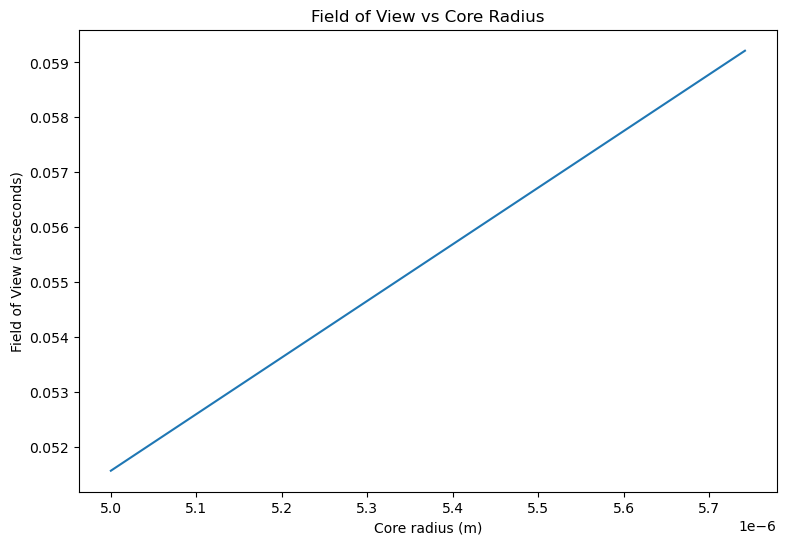

In [32]:
plt.figure(figsize=(9,6))
plt.plot(core_radius_range, FOV_array)
plt.xlabel('Core radius (m)')
plt.ylabel('Field of View (arcseconds)')
plt.title('Field of View vs Core Radius')
plt.show()

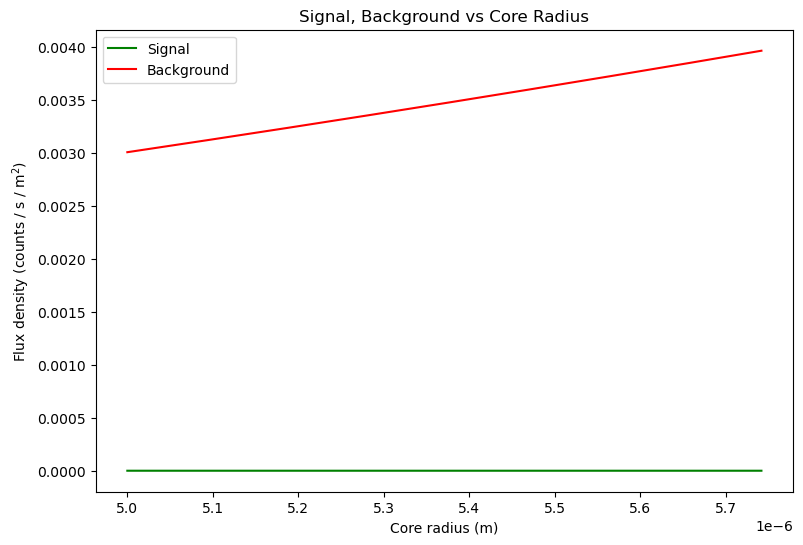

In [33]:
plt.figure(figsize=(9,6))
plt.plot(core_radius_range, signal_array, label='Signal', color='green')
plt.plot(core_radius_range, background_array, label='Background', color='red')
# plt.plot(core_radius_range, snr_rel_array, label='Relative SNR')
plt.xlabel('Core radius (m)')
plt.ylabel('Flux density (counts / s / m$^2$)')
plt.title('Signal, Background vs Core Radius')
plt.legend()

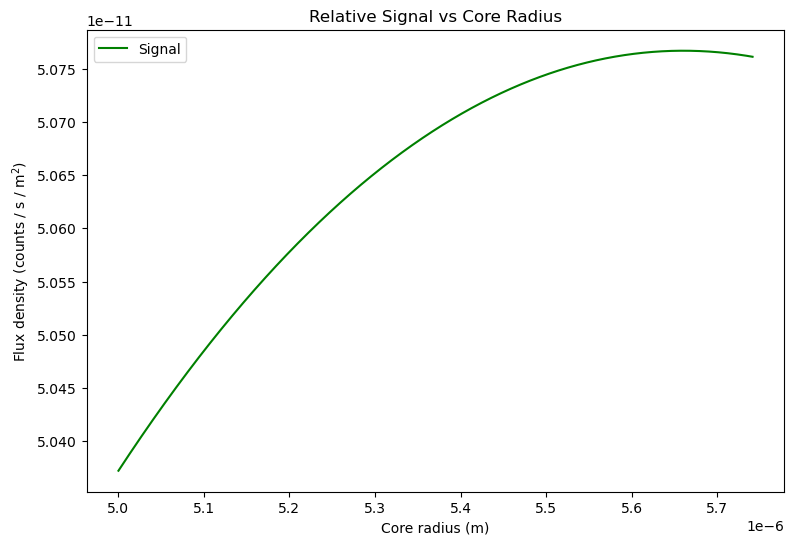

In [34]:
plt.figure(figsize=(9,6))
plt.plot(core_radius_range, relative_signal, label='Signal', color='green')
# plt.plot(core_radius_range, relative_background, label='Background', color='red')
# plt.plot(core_radius_range, snr_rel_array, label='Relative SNR')
plt.xlabel('Core radius (m)')
plt.ylabel('Flux density (counts / s / m$^2$)')
plt.title('Relative Signal vs Core Radius')
plt.legend()

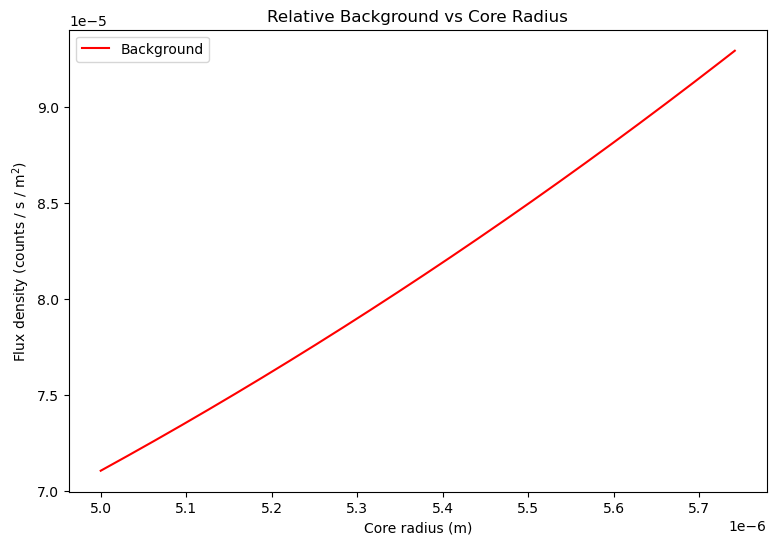

In [35]:
plt.figure(figsize=(9,6))
plt.plot(core_radius_range, relative_background, label='Background', color='red')
plt.xlabel('Core radius (m)')
plt.ylabel('Flux density (counts / s / m$^2$)')
plt.title('Relative Background vs Core Radius')
plt.legend()

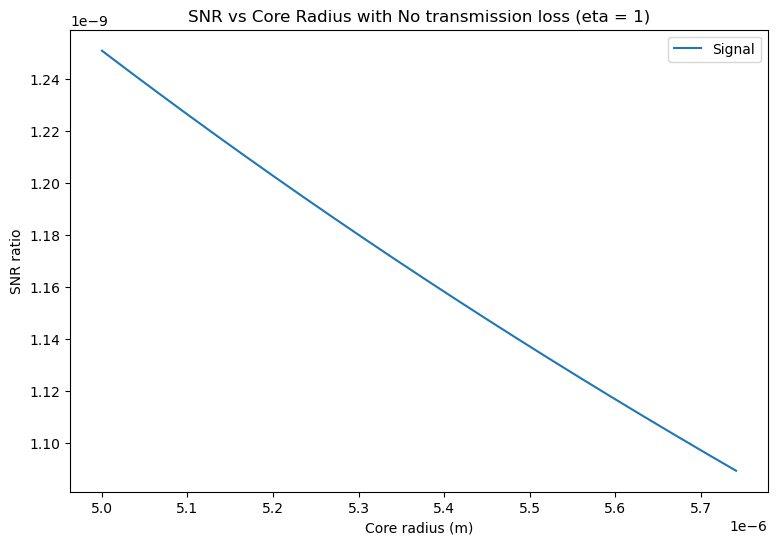

In [36]:
plt.figure(figsize=(9,6))
plt.plot(core_radius_range, snr_array, label='Signal')
# plt.plot(core_radius_range, snr_rel_array, label='Relative SNR')
plt.xlabel('Core radius (m)')
plt.ylabel('SNR ratio')
plt.title('SNR vs Core Radius with No transmission loss (eta = 1)')
plt.legend()

In [38]:
efficiency_coefficient = np.divide(efficiency_array_signal, np.sqrt(efficiency_array_noise)) 
efficiency_coefficient

array([4.77731706, 4.77744217, 4.77756714, ..., 4.83333224, 4.83329439,
       4.83325645], shape=(1484,))

In [39]:
index_overall = np.argmax(efficiency_coefficient)
print(f'The most optimal radius occurs at {core_radius_range[index_overall]} with an efficiency of {efficiency_coefficient[index_overall]}.' )

The most optimal radius occurs at 5.5385e-06 with an efficiency of 4.841123317161426.


<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:6: SyntaxWarning: invalid escape sequence '\e'
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_35652/745832205.py:6: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('Efficiency Coefficient ($\eta_\mathrm{signal}\ /\ \sqrt{\eta_\mathrm{noise}}$)')


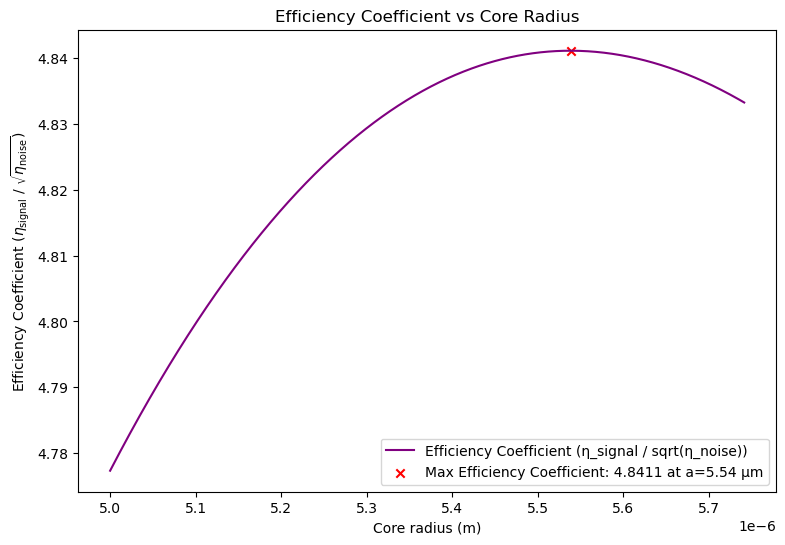

In [40]:
plt.figure(figsize=(9,6))
plt.plot(core_radius_range, efficiency_coefficient, label='Efficiency Coefficient (η_signal / sqrt(η_noise))', color='purple')
plt.scatter(core_radius_range[index_overall], efficiency_coefficient[index_overall], color='red', marker = 'x',
            label=f'Max Efficiency Coefficient: {efficiency_coefficient[index_overall]:.4f} at a={core_radius_range[index_overall]*1e6:.2f} µm')
plt.xlabel('Core radius (m)')
plt.ylabel('Efficiency Coefficient ($\eta_\mathrm{signal}\ /\ \sqrt{\eta_\mathrm{noise}}$)')
plt.title('Efficiency Coefficient vs Core Radius')
plt.legend()

In [41]:
# The relative signal to noise is multiplied by the efficiency coefficient
snr_rel = np.multiply(efficiency_coefficient, snr_array)

In [42]:
index_snr_rel = np.argmax(snr_rel)
print(f'The most optimal radius occurs at {core_radius_range[index_snr_rel]} with a relative SNR of {snr_rel[index_snr_rel]:.4f}.' )

The most optimal radius occurs at 5e-06 with a relative SNR of 0.0000.


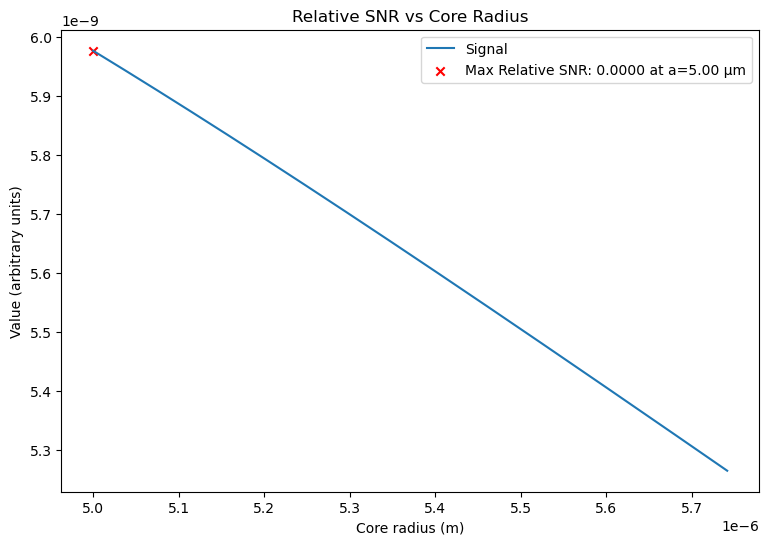

In [43]:
plt.figure(figsize=(9,6))
plt.plot(core_radius_range, snr_rel, label='Signal')
plt.scatter(core_radius_range[index_snr_rel], snr_rel[index_snr_rel], color='red', marker = 'x',
            label=f'Max Relative SNR: {snr_rel[index_snr_rel]:.4f} at a={core_radius_range[index_snr_rel]*1e6:.2f} µm')
# plt.plot(core_radius_range, snr_rel_array, label='Relative SNR')
plt.xlabel('Core radius (m)')
plt.ylabel('Value (arbitrary units)')
plt.title('Relative SNR vs Core Radius')
plt.legend()

## Let's test what happens if we set our fibre from 0 micron to 20 micron

In [45]:
core_radius_range_test = np.linspace(1.2e-6, 50e-6, 500) # from 4 to 20 microns in meters

efficiency_signal_test = np.zeros_like(core_radius_range_test)
efficiency_noise_test = np.zeros_like(core_radius_range_test)

for i, a in enumerate(core_radius_range_test): 
    
    V = 2 * np.pi * (a / lam0) * NA # Calculate the V-number for the given radius
    X_min = 0 + 1e-8
    X_max = V - 1e-8
    # Find the X and Y roots for the given core radius a
    X_root, Y_root = find_root(V, X_min, X_max)
    # define a normalised radius r / a, with maximum at cladding size 125/2 micron
    fibre_rho = np.linspace(0, cladding_radius_max / a, 1000) 
    fibre_r = fibre_rho * a
    # Fibre field
    E_smf, I_smf = calculate_electric_field(fibre_rho, X_root, Y_root)
    # Image field
    E_image, I_image = demagnified_diffraction_limited_E_field(fibre_r, lam0, F, alpha, E_S, Magnification)
    E_flat = np.ones_like(fibre_r) * 1.2
    I_flat = np.abs(E_flat) **2
    # Calculate coupling efficiency
    eta_signal, numerator_signal, denominator = coupling_efficiency_1d(E_image, E_smf, r=fibre_r)
    eta_noise, numerator_noise, denominator = coupling_efficiency_1d(E_flat, E_smf, r=fibre_r)
    efficiency_signal_test[i] = eta_signal
    efficiency_noise_test[i] = eta_noise


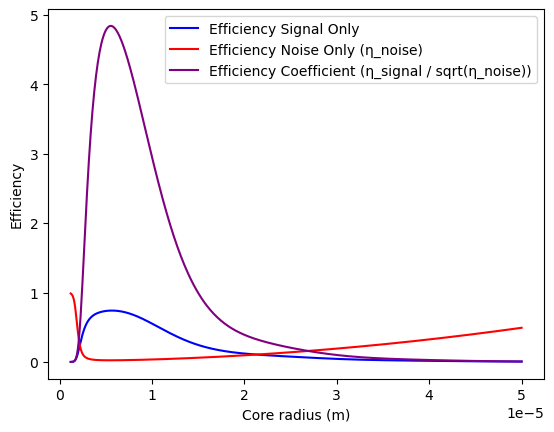

In [47]:
plt.plot(core_radius_range_test, efficiency_signal_test, label='Efficiency Signal Only', color='blue')
plt.plot(core_radius_range_test, efficiency_noise_test, label='Efficiency Noise Only (η_noise)', color='red')
plt.plot(core_radius_range_test, efficiency_signal_test / np.sqrt(efficiency_noise_test), label='Efficiency Coefficient (η_signal / sqrt(η_noise))', color='purple')
plt.xlabel('Core radius (m)')
plt.ylabel('Efficiency')
plt.legend()

In [48]:
efficiency_coefficient.shape

(1484,)

In [ ]:
I_flat = 1.2 **2 # flat intensity of the background noise across the fibre input plane, in normalised units

Signal_test_array = np.zeros_like(core_radius_range_test)
Background_test_array = np.zeros_like(core_radius_range_test)
snr_test_array = np.zeros_like(core_radius_range_test)
FOV_test_array = np.zeros_like(core_radius_range_test)


for i, a in enumerate(core_radius_range_test): 
    fibre_r = np.linspace(0, cladding_radius_max, 10000)
    # core_mask = fibre_r <= a # Create a mask for the core region where the fibre can couple light
    E_image, I_image = demagnified_diffraction_limited_E_field(fibre_r, lam0, F, alpha, E_S, Magnification)
    FOV_value = plate_scale_demag * 2*a
    # Signal_test = 2*np.pi * integrate.simpson(I_image[core_mask] * fibre_r[core_mask], x=fibre_r[core_mask])
    Signal_test = 2*np.pi * integrate.simpson(I_image * fibre_r, x=fibre_r)
    Background_test = np.pi * I_flat * (FOV_value / 2) **2
    snr_test = Signal_test / np.sqrt(Background_test)

    FOV_test_array[i] = FOV_value
    Signal_test_array[i] = Signal_test
    Background_test_array[i] = Background_test
    snr_test_array[i] = snr_test

Text(0.5, 1.0, 'Signal vs Core Radius')

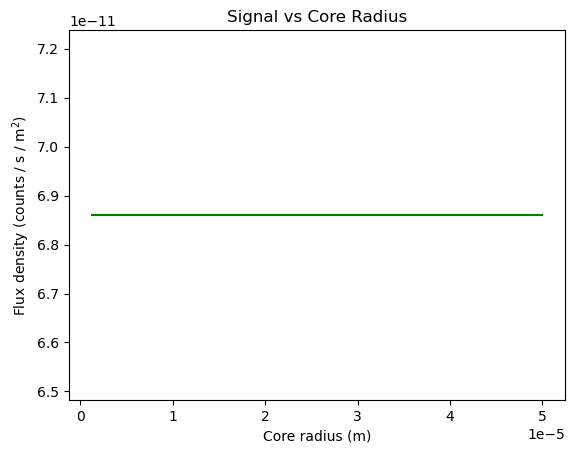

In [50]:
plt.plot(core_radius_range_test, Signal_test_array, label='Signal', color='green')
plt.xlabel('Core radius (m)')
plt.ylabel('Flux density (counts / s / m$^2$)')
plt.title('Signal vs Core Radius')

Text(0, 0.5, 'Flux density (counts / s / m$^2$)')

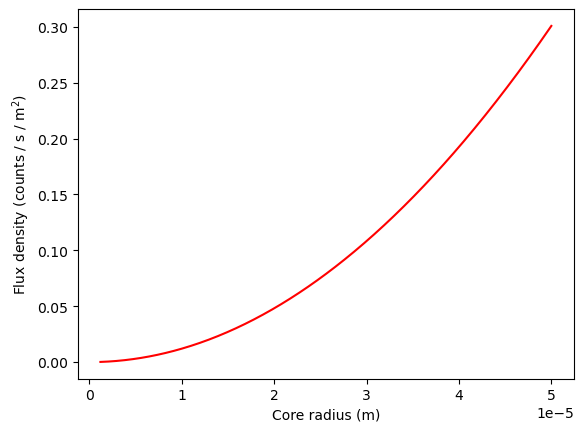

In [51]:
plt.plot(core_radius_range_test, Background_test_array, label='Background', color='red')
plt.xlabel('Core radius (m)')
plt.ylabel('Flux density (counts / s / m$^2$)')

In [52]:
relative_signal_test = efficiency_signal_test * Signal_test_array
relative_background_test = efficiency_noise_test * Background_test_array

Text(0.5, 0, 'Core radius (m)')

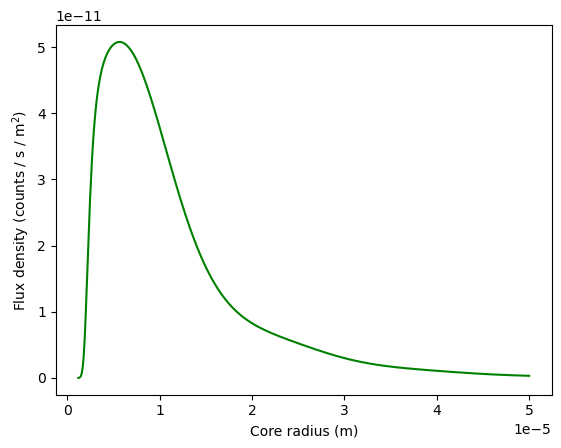

In [53]:
plt.plot(core_radius_range_test, relative_signal_test, label='Relative Signal', color='green')
plt.ylabel('Flux density (counts / s / m$^2$)')
plt.xlabel('Core radius (m)')


Text(0, 0.5, 'Flux density (counts / s / m$^2$)')

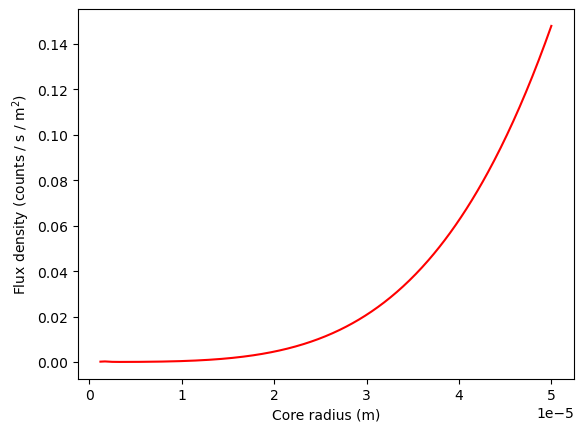

In [54]:
plt.plot(core_radius_range_test, relative_background_test, label='Relative Background', color='red')
plt.xlabel('Core radius (m)')
plt.ylabel('Flux density (counts / s / m$^2$)')

In [55]:
efficiency_coefficient_test = np.divide(efficiency_signal_test, np.sqrt(efficiency_noise_test))

Text(0, 0.5, 'SNR ratio')

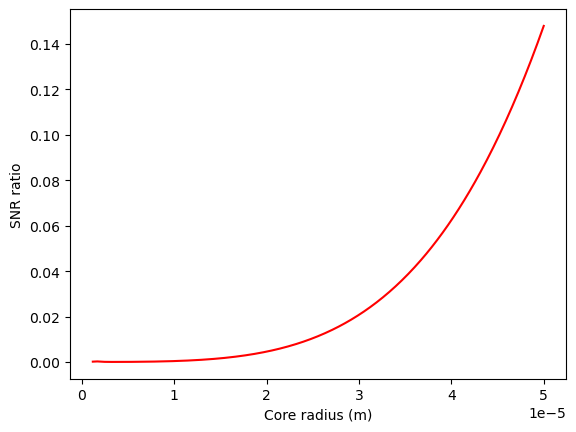

In [57]:
plt.plot(core_radius_range_test, relative_background_test, label='Relative Background', color='red')
plt.xlabel('Core radius (m)')
plt.ylabel('SNR ratio')

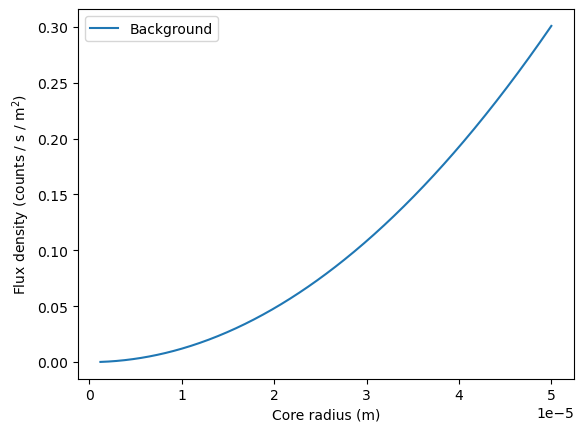

In [59]:
plt.plot(core_radius_range_test, Background_test_array, label='Background')
plt.xlabel('Core radius (m)')
plt.ylabel('Flux density (counts / s / m$^2$)')
plt.legend()

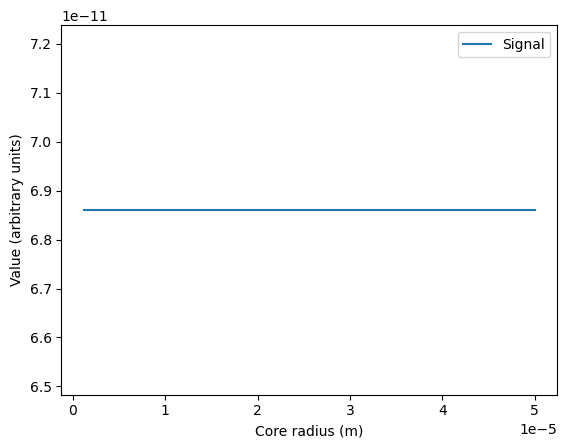

In [61]:
plt.plot(core_radius_range_test, Signal_test_array, label='Signal')
plt.xlabel('Core radius (m)')
plt.ylabel('Value (arbitrary units)')
plt.legend()

In [62]:
relative_snr_test = np.multiply(efficiency_coefficient_test, snr_test_array)
argmax_relative_snr_test = np.argmax(relative_snr_test)
print(f'The most optimal radius occurs at {core_radius_range[argmax_relative_snr_test]} with a relative SNR of {relative_snr_test[argmax_relative_snr_test]:.4e}.' )

The most optimal radius occurs at 5.014000000000001e-06 with a relative SNR of 6.5437e-09.


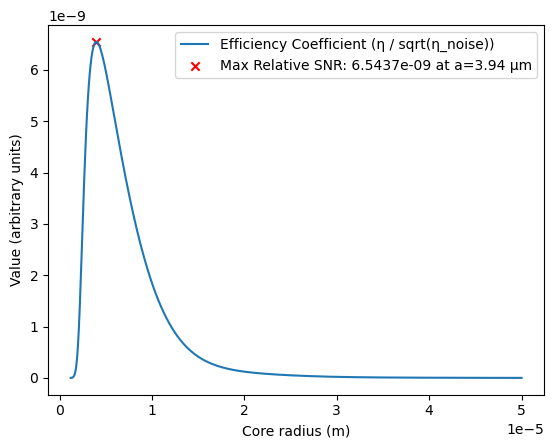

In [64]:
plt.plot(core_radius_range_test, efficiency_coefficient_test * snr_test_array, label='Efficiency Coefficient (η / sqrt(η_noise))')
plt.scatter(core_radius_range_test[argmax_relative_snr_test], relative_snr_test[argmax_relative_snr_test], color='red', marker = 'x',
            label=f'Max Relative SNR: {relative_snr_test[argmax_relative_snr_test]:.4e} at a={core_radius_range_test[argmax_relative_snr_test]*1e6:.2f} µm')
plt.xlabel('Core radius (m)')
plt.ylabel('Value (arbitrary units)')
plt.legend()

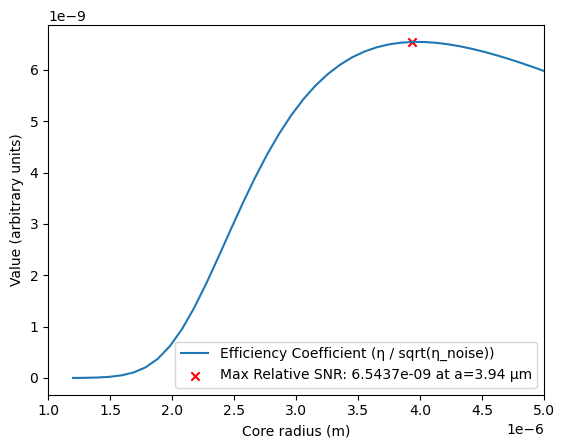

In [66]:
plt.plot(core_radius_range_test, efficiency_coefficient_test * snr_test_array, label='Efficiency Coefficient (η / sqrt(η_noise))')
plt.scatter(core_radius_range_test[argmax_relative_snr_test], relative_snr_test[argmax_relative_snr_test], color='red', marker = 'x',
            label=f'Max Relative SNR: {relative_snr_test[argmax_relative_snr_test]:.4e} at a={core_radius_range_test[argmax_relative_snr_test]*1e6:.2f} µm')
plt.xlabel('Core radius (m)')
plt.ylabel('Value (arbitrary units)')
plt.xlim(1e-6, 5e-6)
plt.legend()

### What if we limit the integral to core radius?

In [ ]:
I_flat = 1.2 **2 # flat intensity of the background noise across the fibre input plane, in normalised units

Signal_test_array = np.zeros_like(core_radius_range_test)
Background_test_array = np.zeros_like(core_radius_range_test)
snr_test_array = np.zeros_like(core_radius_range_test)
FOV_test_array = np.zeros_like(core_radius_range_test)


for i, a in enumerate(core_radius_range_test): 
    fibre_r = np.linspace(0, cladding_radius_max, 10000)
    core_mask = fibre_r <= a # Create a mask for the core region where the fibre can couple light
    E_image, I_image = demagnified_diffraction_limited_E_field(fibre_r, lam0, F, alpha, E_S, Magnification)
    FOV_value = plate_scale_demag * 2*a
    # Signal_test = 2*np.pi * integrate.simpson(I_image[core_mask] * fibre_r[core_mask], x=fibre_r[core_mask])
    Signal_test = 2*np.pi * integrate.simpson(I_image * fibre_r, x=fibre_r)
    Background_test = np.pi * I_flat * (FOV_value / 2) **2
    snr_test = Signal_test / np.sqrt(Background_test)

    FOV_test_array[i] = FOV_value
    Signal_test_array[i] = Signal_test
    Background_test_array[i] = Background_test
    snr_test_array[i] = snr_test